# Prompt to Image (Stable Diffusion) + MDDM (End-to-End)

This notebook loads a Stable Diffusion pipeline and asks for a text prompt to generate an image.

- If the model is gated, set `HF_TOKEN` in your environment or change `model_id`.
- Default model: `runwayml/stable-diffusion-v1-5`.


In [1]:
import os
import torch
from diffusers import StableDiffusionPipeline

# Config
model_id = os.getenv("SD_MODEL_ID", "runwayml/stable-diffusion-v1-5")
token = os.getenv("HF_TOKEN") or os.getenv("HUGGINGFACE_TOKEN")

device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float16 if device == "cuda" else torch.float32

print(f"Loading model: {model_id} on {device} ({dtype})")

pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=dtype,
    token=token,
)
pipe = pipe.to(device)

# Memory-friendly settings
pipe.enable_attention_slicing()
try:
    pipe.enable_xformers_memory_efficient_attention()
    print("xformers enabled")
except Exception as e:
    print("xformers not enabled:", e)


c:\Users\Akshat Kumar\OneDrive - Indian Institute of Technology Bombay\Desktop\IITB Notes\8th_sem\IE 663\Course_Project\mddm_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading model: runwayml/stable-diffusion-v1-5 on cuda (torch.float16)


Loading weights: 100%|██████████| 196/196 [00:20<00:00,  9.39it/s, Materializing param=text_model.final_layer_norm.weight]
CLIPTextModel LOAD REPORT from: C:\Users\Akshat Kumar\.cache\huggingface\hub\models--runwayml--stable-diffusion-v1-5\snapshots\451f4fe16113bff5a5d2269ed5ad43b0592e9a14\text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 396/396 [00:48<00:00,  8.19it/s, Materializing param=visual_projection.weight]
StableDiffusionSafetyChecker LOAD REPORT from: C:\Users\Akshat Kumar\.cache\huggingface\hub\models--runwayml--stable-diffusion-v1-5\snapshots\451f4fe16113bff5a5d2269ed5ad43b0592e9a14\safety_checker
Key                                               | Status     |  | 
---------------------------------

xformers not enabled: Refer to https://github.com/facebookresearch/xformers for more information on how to install xformers


100%|██████████| 30/30 [00:08<00:00,  3.64it/s]


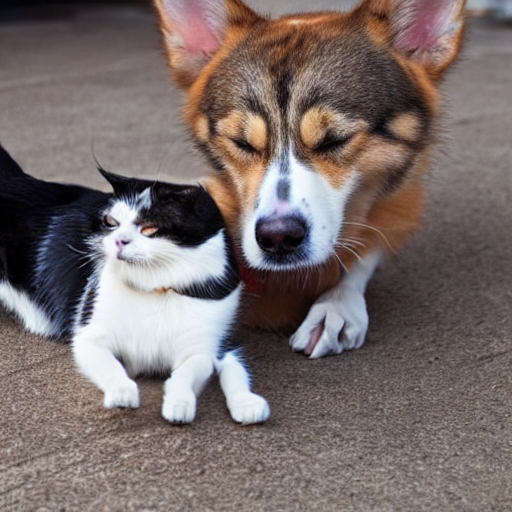

Saved to generated.png


In [2]:
from IPython.display import display

prompt = input("Enter your prompt: ").strip()
if not prompt:
    raise ValueError("Prompt cannot be empty.")

negative_prompt = input("Negative prompt (optional, press Enter to skip): ").strip()
if negative_prompt == "":
    negative_prompt = None

seed_input = input("Seed (optional, press Enter for random): ").strip()
generator = None
if seed_input:
    seed = int(seed_input)
    generator = torch.Generator(device=device).manual_seed(seed)

num_steps = 30
guidance_scale = 7.5

result = pipe(
    prompt=prompt,
    negative_prompt=negative_prompt,
    num_inference_steps=num_steps,
    guidance_scale=guidance_scale,
    generator=generator,
)
image = result.images[0]

out_path = "generated.png"
image.save(out_path)
display(image)
print(f"Saved to {out_path}")



Below is a fully observable workflow implementing MDDM step by step with visualizations.


# MDDM End-to-End Implementation (Transparent & Verifiable)

This section implements the MDDM paper **cell-by-cell** so every stage is explicit, testable, and reproducible.
We will: define a message, encode it into noise via a Cardan grille, generate a stego image using DDIM, invert the image, and decode the message.


## Cell A: Imports and Global Configuration
This cell centralizes dependencies and experiment settings (image size, steps, guidance, seed).
All later cells assume these variables exist.


In [1]:
# Core deps
import os
import math
import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.stats import norm

# Diffusers
from diffusers import StableDiffusionPipeline, DDIMScheduler
try:
    from diffusers import DDIMInverseScheduler
    HAS_DDIM_INVERSE = True
except Exception:
    HAS_DDIM_INVERSE = False

from IPython.display import display

# Runtime
device = 'cuda' if torch.cuda.is_available() else 'cpu'
dtype = torch.float16 if device == 'cuda' else torch.float32
print('device:', device, 'dtype:', dtype)

# Experiment settings (edit freely)
image_size = 512
num_steps = 30
guidance_scale = 7.5
eta = 0.0  # DDIM deterministic sampling
seed = 1234

prompt = 'a photo of an astronaut riding a horse, high quality'
negative_prompt = None
message_text = 'MDDM demo: hidden message'


c:\Users\Akshat Kumar\OneDrive - Indian Institute of Technology Bombay\Desktop\IITB Notes\8th_sem\IE 663\Course_Project\mddm_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: cuda dtype: torch.float16


## Cell 1: Hidden Message Definition
Convert the human?readable message into a binary sequence that will be embedded into the noise.


In [2]:
# Message ? bits utilities
def text_to_bits(text):
    data = text.encode('utf-8')
    bits = []
    for b in data:
        bits.extend([(b >> i) & 1 for i in range(7, -1, -1)])
    return bits

def bits_to_text(bits):
    if len(bits) % 8 != 0:
        bits = bits[:len(bits) - (len(bits) % 8)]
    out = []
    for i in range(0, len(bits), 8):
        val = 0
        for j in range(8):
            val = (val << 1) | int(bits[i + j])
        out.append(val)
    try:
        return bytes(out).decode('utf-8', errors='ignore')
    except Exception:
        return ''

bits = text_to_bits(message_text)
print('Message:', message_text)
print('Bit length:', len(bits))
print('Bits (first 128):', bits[:128])


Message: MDDM demo: hidden message
Bit length: 200
Bits (first 128): [0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1]


## Cell 2: Message Encoding into Noise (x_T)
Create the Cardan grille, compute truncation threshold **k**, and construct the encoded noise tensor.
We also plot the overall noise distribution to validate approximate Gaussianity.


xT shape: torch.Size([1, 4, 64, 64])
k (threshold): 2.5061022522487013
Lmax approx: 5198
Mean: 0.0008196907583624125 Var: 0.9905336499214172


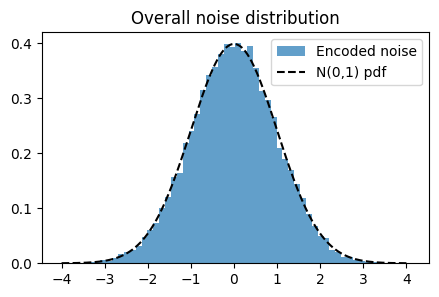

In [3]:
# Cardan grille and truncated normal sampling
def generate_cardan_grille(total, length, seed=None):
    g = torch.Generator(device='cpu')
    if seed is not None:
        g.manual_seed(int(seed))
    return torch.randperm(total, generator=g)[:length]

def truncation_threshold(total, length):
    # k = Phi^-1(1 - l/(2*total))
    p = 1.0 - (length / (2.0 * total))
    return float(norm.ppf(p))

def sample_truncated_normal(n, low=None, high=None, generator=None):
    if n <= 0:
        return torch.empty((0,), dtype=torch.float32)
    out = []
    needed = n
    while needed > 0:
        batch = torch.randn((max(needed * 2, 1024),), generator=generator)
        mask = torch.ones_like(batch, dtype=torch.bool)
        if low is not None:
            mask &= (batch > low)
        if high is not None:
            mask &= (batch <= high)
        accepted = batch[mask]
        if accepted.numel() > 0:
            out.append(accepted)
            needed -= accepted.numel()
    return torch.cat(out)[:n]

def encode_message_to_noise(bits, c=4, h=64, w=64, seed=None):
    total = c * h * w
    length = len(bits)
    if length > total:
        raise ValueError('Message too long for noise size')

    # Robust capacity estimate (paper uses tails beyond |x|>1)
    Lmax = int(2.0 * (1.0 - norm.cdf(1.0)) * total)
    if length > Lmax:
        print('Warning: length > robust capacity Lmax =', Lmax)

    k = truncation_threshold(total, length)
    cg = generate_cardan_grille(total, length, seed=seed)

    gen = torch.Generator(device='cpu')
    if seed is not None:
        gen.manual_seed(int(seed) + 12345)

    noise = torch.empty((total,), dtype=torch.float32)
    bits_t = torch.tensor(bits, dtype=torch.int64)

    left_idx = cg[bits_t == 0]
    right_idx = cg[bits_t == 1]

    # Encode bits into tails
    if left_idx.numel() > 0:
        noise[left_idx] = sample_truncated_normal(left_idx.numel(), low=None, high=-k, generator=gen)
    if right_idx.numel() > 0:
        noise[right_idx] = sample_truncated_normal(right_idx.numel(), low=k, high=None, generator=gen)

    # Fill remaining positions with central samples
    mask = torch.ones((total,), dtype=torch.bool)
    mask[cg] = False
    central_idx = torch.where(mask)[0]
    if central_idx.numel() > 0:
        noise[central_idx] = sample_truncated_normal(central_idx.numel(), low=-k, high=k, generator=gen)

    return noise.view(1, c, h, w), cg, k, Lmax

# Encode message into noise
c, h, w = 4, image_size // 8, image_size // 8
xT, cg, k, Lmax = encode_message_to_noise(bits, c=c, h=h, w=w, seed=seed)

print('xT shape:', xT.shape)
print('k (threshold):', k)
print('Lmax approx:', Lmax)
print('Mean:', xT.mean().item(), 'Var:', xT.var().item())

# Overall distribution vs N(0,1)
vals = xT.view(-1).numpy()
plt.figure(figsize=(5,3))
plt.hist(vals, bins=60, density=True, alpha=0.7, label='Encoded noise')
x = np.linspace(-4, 4, 400)
plt.plot(x, norm.pdf(x), 'k--', label='N(0,1) pdf')
plt.title('Overall noise distribution')
plt.legend()
plt.show()


## Cell 3: Noise Validation & Tail Separation
Plot distributions for message vs non?message positions and verify tail separation for bit 0/1.


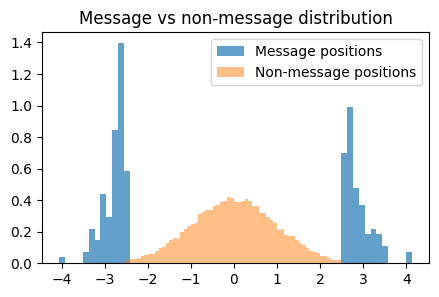

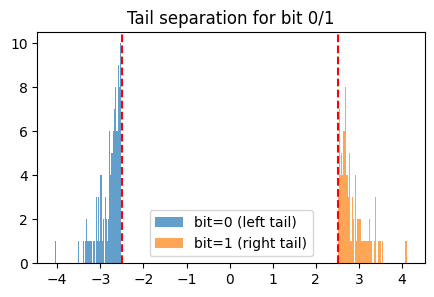

bit=0 mean: -2.7807528972625732 bit=1 mean: 2.862592935562134


In [4]:
flat = xT.view(-1)
msg_vals = flat[cg]
mask = torch.ones_like(flat, dtype=torch.bool)
mask[cg] = False
non_msg_vals = flat[mask]

bits_t = torch.tensor(bits, dtype=torch.int64)
vals_bit0 = msg_vals[bits_t == 0]
vals_bit1 = msg_vals[bits_t == 1]

plt.figure(figsize=(5,3))
plt.hist(msg_vals.numpy(), bins=60, density=True, alpha=0.7, label='Message positions')
plt.hist(non_msg_vals.numpy(), bins=60, density=True, alpha=0.5, label='Non-message positions')
plt.title('Message vs non-message distribution')
plt.legend()
plt.show()

plt.figure(figsize=(5,3))
plt.hist(vals_bit0.numpy(), bins=60, alpha=0.7, label='bit=0 (left tail)')
plt.hist(vals_bit1.numpy(), bins=60, alpha=0.7, label='bit=1 (right tail)')
plt.axvline(-k, color='r', linestyle='--')
plt.axvline(k, color='r', linestyle='--')
plt.title('Tail separation for bit 0/1')
plt.legend()
plt.show()

print('bit=0 mean:', vals_bit0.mean().item(), 'bit=1 mean:', vals_bit1.mean().item())


## Cell 4: Image Generation from Encoded Noise (DDIM)
Inject x_T into Stable Diffusion using deterministic DDIM sampling and generate the stego image.


Loading weights: 100%|██████████| 196/196 [00:00<00:00, 224.73it/s, Materializing param=text_model.final_layer_norm.weight]
CLIPTextModel LOAD REPORT from: C:\Users\Akshat Kumar\.cache\huggingface\hub\models--runwayml--stable-diffusion-v1-5\snapshots\451f4fe16113bff5a5d2269ed5ad43b0592e9a14\text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 396/396 [00:01<00:00, 199.39it/s, Materializing param=visual_projection.weight]
StableDiffusionSafetyChecker LOAD REPORT from: C:\Users\Akshat Kumar\.cache\huggingface\hub\models--runwayml--stable-diffusion-v1-5\snapshots\451f4fe16113bff5a5d2269ed5ad43b0592e9a14\safety_checker
Key                                               | Status     |  | 
-------------------------------

xformers not enabled: Refer to https://github.com/facebookresearch/xformers for more information on how to install xformers


100%|██████████| 30/30 [00:05<00:00,  5.23it/s]


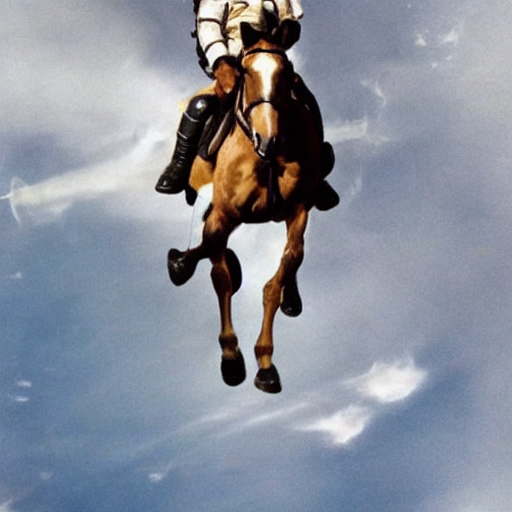

Saved: mddm_stego.png


In [5]:
model_id = os.getenv('SD_MODEL_ID', 'runwayml/stable-diffusion-v1-5')
token = os.getenv('HF_TOKEN') or os.getenv('HUGGINGFACE_TOKEN')

if 'pipe' not in globals():
    pipe = StableDiffusionPipeline.from_pretrained(
        model_id,
        torch_dtype=dtype,
        token=token,
        use_safetensors=True,
    )
pipe.scheduler = DDIMScheduler.from_config(pipe.scheduler.config)
pipe = pipe.to(device)
pipe.enable_attention_slicing()
try:
    pipe.enable_xformers_memory_efficient_attention()
except Exception as e:
    print('xformers not enabled:', e)

init_sigma = pipe.scheduler.init_noise_sigma
latents = xT.to(device, dtype=dtype) * init_sigma

with torch.no_grad():
    result = pipe(
        prompt=prompt,
        negative_prompt=negative_prompt,
        num_inference_steps=num_steps,
        guidance_scale=guidance_scale,
        eta=eta,
        latents=latents,
        output_type='pil',
    )

stego_image = result.images[0]
stego_image.save('mddm_stego.png')
display(stego_image)
print('Saved: mddm_stego.png')


## Cell 5: Reverse Diffusion / Inversion (DDIM)
Invert the generated image to recover the estimated noise x_T'.


In [6]:
if not HAS_DDIM_INVERSE:
    raise RuntimeError('DDIMInverseScheduler not available in this diffusers version.')

def pil_to_latents(pipe, pil_image):
    image = np.array(pil_image).astype(np.float32) / 255.0
    if image.ndim == 2:
        image = np.stack([image] * 3, axis=-1)
    image = image[None].transpose(0, 3, 1, 2)
    image = torch.from_numpy(image).to(device, dtype=dtype)
    image = 2.0 * image - 1.0
    with torch.no_grad():
        latents = pipe.vae.encode(image).latent_dist.sample()
    scaling = getattr(pipe.vae.config, 'scaling_factor', 0.18215)
    return latents * scaling

def get_prompt_embeds(pipe, prompt, negative_prompt=None, do_cfg=True):
    if hasattr(pipe, 'encode_prompt'):
        pe, ne = pipe.encode_prompt(
            prompt=prompt,
            device=device,
            num_images_per_prompt=1,
            do_classifier_free_guidance=do_cfg,
            negative_prompt=negative_prompt,
        )
        return torch.cat([ne, pe]) if do_cfg else pe
    return pipe._encode_prompt(prompt, device, 1, do_cfg, negative_prompt)

def ddim_invert(pipe, x0_latents, prompt, negative_prompt=None, num_steps=30, guidance_scale=7.5):
    inv_scheduler = DDIMInverseScheduler.from_config(pipe.scheduler.config)
    inv_scheduler.set_timesteps(num_steps)
    do_cfg = guidance_scale > 1.0
    prompt_embeds = get_prompt_embeds(pipe, prompt, negative_prompt, do_cfg=do_cfg)

    latents = x0_latents
    with torch.no_grad():
        for t in inv_scheduler.timesteps:
            latent_model_input = torch.cat([latents] * 2) if do_cfg else latents
            noise_pred = pipe.unet(latent_model_input, t, encoder_hidden_states=prompt_embeds).sample
            if do_cfg:
                noise_uncond, noise_text = noise_pred.chunk(2)
                noise_pred = noise_uncond + guidance_scale * (noise_text - noise_uncond)
            latents = inv_scheduler.step(noise_pred, t, latents).prev_sample
    return latents

x0_latents = pil_to_latents(pipe, stego_image)
xT_hat_latents = ddim_invert(pipe, x0_latents, prompt, negative_prompt, num_steps, guidance_scale)
xT_hat = (xT_hat_latents / init_sigma).detach().cpu()

print('Recovered xT_hat shape:', xT_hat.shape)
print('xT_hat mean:', xT_hat.mean().item(), 'var:', xT_hat.var().item())


The config attributes {'skip_prk_steps': True} were passed to DDIMInverseScheduler, but are not expected and will be ignored. Please verify your scheduler_config.json configuration file.


Recovered xT_hat shape: torch.Size([1, 4, 64, 64])
xT_hat mean: -0.0013742446899414062 var: 0.974609375


## Cell 6: Noise Comparison (x_T vs x_T')
Quantitatively compare mean/variance and visually inspect recovery fidelity.


Original mean/var: 0.0008196907583624125 0.9905336499214172
Recovered mean/var: -0.0013742446899414062 0.974609375
Sign consistency @CG: 1.0


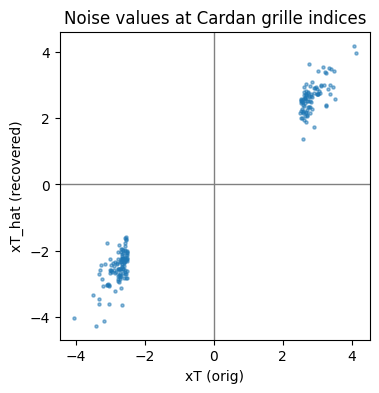

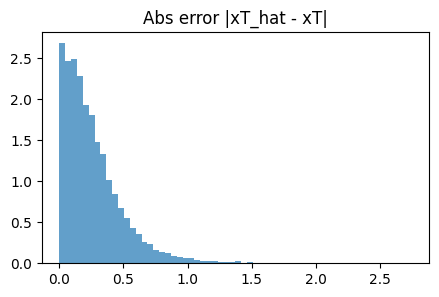

In [7]:
orig = xT.view(-1)
rec = xT_hat.view(-1)

print('Original mean/var:', orig.mean().item(), orig.var().item())
print('Recovered mean/var:', rec.mean().item(), rec.var().item())

sign_consistency = (orig[cg] > 0) == (rec[cg] > 0)
sign_acc = sign_consistency.float().mean().item()
print('Sign consistency @CG:', sign_acc)

plt.figure(figsize=(4,4))
plt.scatter(orig[cg].numpy(), rec[cg].numpy(), s=5, alpha=0.5)
plt.xlabel('xT (orig)')
plt.ylabel('xT_hat (recovered)')
plt.title('Noise values at Cardan grille indices')
plt.axhline(0, color='gray', lw=1)
plt.axvline(0, color='gray', lw=1)
plt.show()

diff = (rec - orig).numpy()
plt.figure(figsize=(5,3))
plt.hist(np.abs(diff), bins=60, density=True, alpha=0.7)
plt.title('Abs error |xT_hat - xT|')
plt.show()


## Cell 7: Message Decoding
Decode bits via sign at Cardan grille indices and reconstruct text.


In [8]:
def extract_bits_from_noise(noise, cg):
    flat = noise.view(-1)
    vals = flat[cg]
    return (vals > 0).int().cpu().tolist()

bits_hat = extract_bits_from_noise(xT_hat, cg)
decoded_text = bits_to_text(bits_hat)

print('Decoded text:', decoded_text)


Decoded text: MDDM demo: hidden message


## Cell 8: End-to-End Verification
Report original vs decoded message and compute bit accuracy.


In [9]:
correct = sum(int(a == b) for a, b in zip(bits, bits_hat))
acc = correct / len(bits) if bits else 0.0

print('Original message:', message_text)
print('Decoded message :', decoded_text)
print('Bit accuracy    :', acc)
print('Bit error rate  :', 1.0 - acc)


Original message: MDDM demo: hidden message
Decoded message : MDDM demo: hidden message
Bit accuracy    : 1.0
Bit error rate  : 0.0
